Data Loading and Exploration

In [4]:
from datasets import load_dataset

Loading the dataset from HuggingFace

In [5]:
ds = load_dataset("coastalchp/ledgar")


README.md: 0.00B [00:00, ?B/s]

c:\dev\Legal_Clause_Classification\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\soham_ai\.cache\huggingface\hub\datasets--coastalchp--ledgar. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.54M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/2.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [8]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
})

In [10]:
#Excerpt of the dataset from train folder
ds['train'][:10]

{'text': ['Except as otherwise set forth in this Debenture, the Company, for itself and its legal representatives, successors assigns, expressly waives presentment, protest, demand, notice of dishonor, nonpayment, maturity, presentment purpose accelerating diligence collection.',
  'No ERISA Event has occurred or is reasonably expected to occur that, when taken together with all other such Events for which liability occur, could be result in a Material Adverse Effect. Neither Borrower nor any Affiliate maintains contributes obligation maintain contribute Multiemployer Plan Plan, otherwise under Title IV of ERISA.',
  'This Amendment may be executed by one or more of the parties hereto on any number separate counterparts, and all said counterparts taken together shall deemed to constitute same instrument. delivered facsimile other electronic transmission relevant signature pages hereof.',
  'From time to time, as and when required by the Surviving Corporation or its successors assigns, 

Defining Each Split and Converting to Pandas DF

In [31]:
train_df = ds['train'].to_pandas()
test_ds= ds['test'].to_pandas()
validation_ds = ds['validation'].to_pandas()

In [32]:
train_df.head()

,text,label
0,Except as otherwise set forth in this Debentur...,97
1,No ERISA Event has occurred or is reasonably e...,39
2,This Amendment may be executed by one or more ...,26
3,"From time to time, as and when required by the...",45
4,"Commencing March 7, 2016 and during the Employ...",11


In [34]:
train_df.isnull().sum()

#No null values in the dataset

text     0
label    0
dtype: int64

In [36]:
train_df.dtypes

text       str
label    int64
dtype: object

Analyzing Label distribution

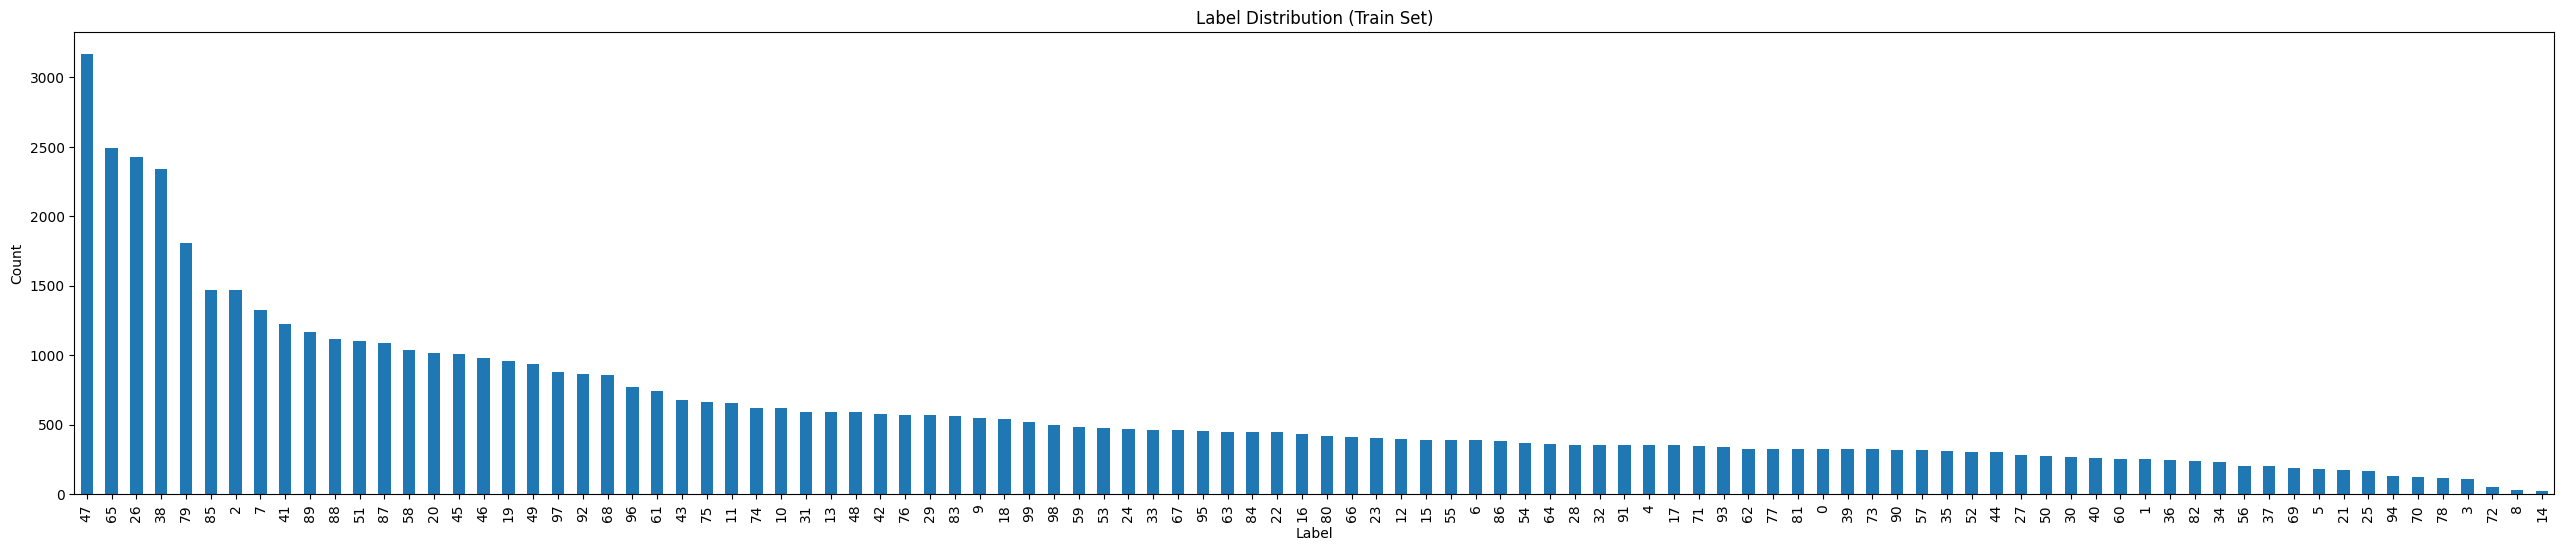

In [42]:
import matplotlib.pyplot as plt

label_counts = train_df['label'].value_counts()

plt.figure(figsize=(32,6))
label_counts.plot(kind='bar')
plt.title("Label Distribution (Train Set)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()